# Examen práctico — Q-Learning tabular con Pac-Man

En este ejercicio trabajaremos con una versión pequeña de Pac-Man diseñada para poder resolverse completamente mediante **Q-Learning tabular**.

La lógica es la misma usada previamente:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

y:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma \max_{a'}Q(S_{t+1},a')
-
Q(S_t,A_t)
\right].
$$

## Objetivo

Implementar un agente Q-Learning capaz de aprender una política que permita a Pac-Man:

- comer tantas comidas como sea posible;
- evitar al fantasma;
- reducir movimientos innecesarios.

> La implementación del ambiente y la visualización ya están disponibles.  
> La tarea consiste en implementar **el agente y su proceso de aprendizaje**.


## 1. Importaciones y ambiente


In [1]:
# Configuración de rutas: funciona igual en local y en Google Colab.
import sys
from pathlib import Path


def find_project_root(module="tabular_pacman_env.py", start=None):
    """Busca hacia arriba la carpeta que contiene src/<module>."""
    start = Path(start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / module).exists():
            return candidate
    return None


PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is None:
    try:
        from google.colab import drive  # solo existe en Colab

        drive.mount("/content/drive")
        PROJECT_ROOT = find_project_root(
            start="/content/drive/MyDrive/Courses/SI3003 - Inteligencia Artificial/Clase05/pacman"
        )
    except ImportError:
        pass

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "No se encontró src/tabular_pacman_env.py. "
        "Ejecute el notebook desde la carpeta del proyecto (practicaP1)."
    )

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: C:\Users\diego\Intro_IA\codechallenges\P1\practicaP1


In [2]:
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

from tabular_pacman_env import (
    TabularPacmanEnv,
    ACTIONS,
)

env = TabularPacmanEnv(seed=7)

print("Número de estados:", env.n_states)
print("Número de acciones:", env.n_actions)


Número de estados: 1944
Número de acciones: 4


## 2. El estado de Pac-Man

Para mantener una Q-table de tamaño manejable utilizaremos la representación:

$$
s=(p,g,n)
$$

donde:

- $p$: posición de Pac-Man;
- $g$: posición del fantasma;
- $n$: número de comidas que permanecen en el tablero.

El ambiente mantiene internamente la posición exacta de cada comida para poder simular y visualizar el juego. Sin embargo, **esa configuración completa no forma parte del estado que recibe la Q-table**.

Por tanto:

$$
n_{\text{states}}
=
n_p\,n_g\,(N_{\text{food}}+1).
$$

Esta es una **representación simplificada del estado**: dos configuraciones distintas de comida pueden compartir el mismo $(p,g,n)$.


Estado codificado: 47
Estado decodificado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)


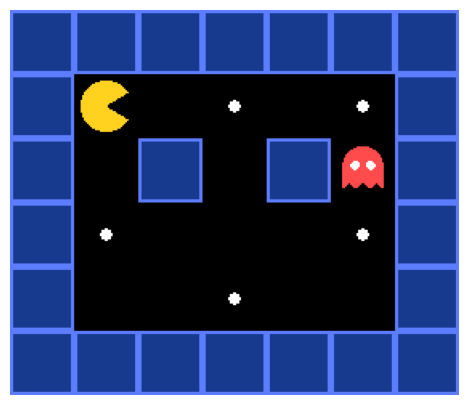

In [3]:
state = env.reset(seed=7)

print("Estado codificado:", state)
print("Estado decodificado:", env.decode_state(state))

frame = env.render()

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.show()


### Pregunta 1

Dos tableros pueden tener:

- la misma posición de Pac-Man;
- la misma posición del fantasma;
- el mismo número de comidas restantes;

pero las comidas pueden estar ubicadas en lugares diferentes.

¿Representaría nuestra Q-table ambos tableros como el mismo estado o como estados diferentes? Explique.

**Respuesta.** Los representaría como **el mismo estado**.

`encode_state` solo usa tres cosas:

```python
(p * n_celdas + g) * (max_food + 1) + food_remaining
```

es decir la posición de Pac-Man, la del fantasma y la *cantidad* de comidas,
nunca *cuáles* comidas siguen en el tablero. Dos tableros que coincidan en
$(p,g,n)$ caen en la misma fila de la Q-table aunque la comida esté en
lugares distintos.

Esto es **aliasing de estado**: la Q-table promedia situaciones que en
realidad exigen acciones opuestas. Con $n=1$, por ejemplo, la última comida
puede estar en $(1,3)$ o en $(3,1)$ — extremos opuestos del laberinto — y el
agente ve exactamente el mismo estado, así que aprende un único valor para
"ir a la derecha" mezclando ambos casos.

La consecuencia es medible: en la evaluación final el agente **nunca muere**
(0/200 episodios perdidos) pero **33/200 episodios agotan `max_steps`**,
porque la política greedy queda oscilando entre dos celdas sin poder
distinguir hacia qué lado está la comida que falta. Guardar la configuración
exacta de comida arreglaría el problema, pero el espacio de estados pasaría
de $18\cdot18\cdot6=1944$ a $18\cdot18\cdot2^5=10\,368$ estados.


## 3. Acciones


In [4]:
print(ACTIONS)
print("Acciones legales desde el estado inicial:")
print([ACTIONS[a] for a in env.get_legal_actions()])


{0: 'up', 1: 'right', 2: 'down', 3: 'left'}
Acciones legales desde el estado inicial:
['right', 'down']


Las acciones disponibles son:

| Código | Acción |
|---:|---|
| 0 | arriba |
| 1 | derecha |
| 2 | abajo |
| 3 | izquierda |

El ambiente evita atravesar paredes.


## 4. Observar una transición


In [5]:
state = env.reset(seed=7)

action = env.get_legal_actions()[0]

next_state, reward, done, info = env.step(action)

print("S_t       =", state)
print("A_t       =", ACTIONS[action])
print("R_(t+1)   =", reward)
print("S_(t+1)   =", next_state)
print("done      =", done)
print()
print("S_(t+1) decodificado:")
print(env.decode_state(next_state))


S_t       = 47
A_t       = right
R_(t+1)   = -1
S_(t+1)   = 185
done      = False

S_(t+1) decodificado:
PacmanState(pacman=(1, 2), ghost=(3, 5), food_remaining=5)


La transición observada tiene la forma:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

### Pregunta 2

¿Cuáles de los siguientes valores son entregados directamente por el ambiente y cuáles debe aprender/estimar el agente?

- $R_{t+1}$
- $S_{t+1}$
- $Q(S_t,A_t)$
- $\max_{a'}Q(S_{t+1},a')$

**Respuesta.**

| Valor | ¿Quién lo entrega? |
|---|---|
| $R_{t+1}$ | **El ambiente**, directamente en `env.step(action)`. |
| $S_{t+1}$ | **El ambiente**, directamente en `env.step(action)`. |
| $Q(S_t,A_t)$ | **El agente**: es su propia estimación, guardada en `Q[state, action]`. |
| $\max_{a'}Q(S_{t+1},a')$ | **El agente**: se calcula sobre su Q-table, `np.max(Q[next_state])`. |

En la transición mostrada arriba el ambiente entregó $R_{t+1}=-1$ y
$S_{t+1}=185$; los dos Q-values no existen en el ambiente, son números que el
agente inventa en 0 y va corrigiendo.

El detalle importante es que el objetivo de aprendizaje
$R_{t+1}+\gamma\max_{a'}Q(S_{t+1},a')$ **mezcla ambas fuentes**: un dato real
del ambiente ($R_{t+1}$) más una estimación propia todavía imperfecta. Eso es
*bootstrapping*, y es la razón por la que el agente puede aprender sin conocer
el modelo de transición del ambiente.


## 5. Q-table


Construya una Q-table inicializada en cero.

Debe tener dimensiones:

$$
n_{\text{states}}\times n_{\text{actions}}.
$$


In [6]:
# TODO 1 — Inicializar la Q-table
#
# Recibe / ya está disponible:
#   - env.n_states : número total de estados discretos del ambiente.
#   - env.n_actions: número total de acciones posibles.
#
# Debe implementar:
#   - Una matriz NumPy Q con una fila por estado y una columna por acción.
#   - Todos los valores deben iniciar en 0.
#
# Resultado esperado:
#   Q.shape == (env.n_states, env.n_actions)

# Una fila por estado, una columna por acción.
# Inicializar en cero significa "no tengo ninguna preferencia todavía":
# al principio todas las acciones parecen igual de buenas y el agente
# debe descubrir el valor de cada par (s, a) con la experiencia.
Q = np.zeros((env.n_states, env.n_actions))

print("Valores que el agente debe aprender:", Q.size)


Valores que el agente debe aprender: 7776


In [7]:
# Esta celda debe ejecutarse cuando TODO 1 esté correcto.

print("Shape esperado:", (env.n_states, env.n_actions))
print("Shape obtenido :", Q.shape)

assert Q.shape == (env.n_states, env.n_actions)
assert np.all(Q == 0)

print("✓ Q-table creada correctamente")


Shape esperado: (1944, 4)
Shape obtenido : (1944, 4)
✓ Q-table creada correctamente


## 6. Política ε-greedy


Implemente:

$$
A_t=
\begin{cases}
\text{acción aleatoria}, & \text{con probabilidad }\epsilon\\[4pt]
\arg\max_a Q(S_t,a), & \text{con probabilidad }1-\epsilon
\end{cases}
$$

Use únicamente las **acciones legales** del estado actual.

Si varias acciones tienen el mismo máximo Q-value, seleccione aleatoriamente entre ellas.


In [8]:
# ============================================================
# TODO 2 — Política epsilon-greedy
# ============================================================
#
# Con probabilidad epsilon  -> acción aleatoria entre las legales (explorar).
# Con probabilidad 1-epsilon -> acción legal con mayor Q(state, a) (explotar).
#
# Nunca se seleccionan acciones ilegales: el argmax se calcula
# únicamente sobre env.get_legal_actions().
# ============================================================

def choose_action(Q, state, epsilon, env):
    legal_actions = env.get_legal_actions()

    # --- Exploración -------------------------------------------------
    if random.random() < epsilon:
        return random.choice(legal_actions)

    # --- Explotación -------------------------------------------------
    # Solo se miran las columnas de las acciones legales.
    values = np.array([Q[state, action] for action in legal_actions])
    best_value = values.max()

    # Desempate aleatorio: con la Q-table en cero todos los valores son
    # iguales y un argmax "puro" devolvería siempre la misma acción,
    # sesgando la exploración inicial hacia una sola dirección.
    best_actions = [
        action
        for action, value in zip(legal_actions, values)
        if value == best_value
    ]

    return int(random.choice(best_actions))


# Comprobación rápida: la acción devuelta siempre debe ser legal.
state = env.reset(seed=7)
legal = env.get_legal_actions()
assert all(choose_action(Q, state, 1.0, env) in legal for _ in range(200))
assert all(choose_action(Q, state, 0.0, env) in legal for _ in range(200))
print("Acciones legales desde el estado inicial:", [ACTIONS[a] for a in legal])
print("✓ choose_action solo devuelve acciones legales")


Acciones legales desde el estado inicial: ['right', 'down']
✓ choose_action solo devuelve acciones legales


### Pregunta 3

Si $\epsilon=0.10$:

1. ¿cuál es la probabilidad de explorar?
2. ¿cuál es la probabilidad de explotar?
3. ¿qué ocurre cuando todos los Q-values iniciales son iguales?

**Respuesta.**

1. **Probabilidad de explorar: $\epsilon = 0.10$**, es decir 10 %. En ese caso
   la acción se elige al azar entre las legales.
2. **Probabilidad de explotar: $1-\epsilon = 0.90$**, es decir 90 %. Se toma
   $\arg\max_a Q(s,a)$ restringido a las acciones legales.

   (Matiz: la probabilidad de terminar ejecutando una acción *distinta* de la
   greedy es menor que 10 %, porque la rama aleatoria también puede caer sobre
   la mejor acción. Con 2 acciones legales, explorar devuelve la greedy la
   mitad de las veces.)

3. **Si todos los Q-values iniciales son iguales** — que es justo lo que pasa
   en el episodio 1, con `Q = np.zeros(...)` — el $\arg\max$ queda empatado y
   no aporta información: explotar es indistinguible de explorar y el agente
   hace una **caminata aleatoria** sobre las acciones legales.

   Por eso `choose_action` desempata con `random.choice` entre todas las
   acciones de valor máximo. Si se usara `np.argmax` a secas, siempre se
   devolvería la primera acción legal del empate y el agente arrancaría
   sesgado hacia una sola dirección, explorando mucho peor el laberinto.


## 7. Actualización Q-Learning


Para cada transición utilice:

$$
\text{TD target}
=
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
$$

$$
\text{TD error}
=
\text{TD target}
-
Q(S_t,A_t)
$$

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)+\alpha(\text{TD error})
$$

Cuando $S_{t+1}$ sea terminal:

$$
\max_{a'}Q(S_{t+1},a')=0.
$$


In [9]:
# ============================================================
# TODO 3
# Implemente una actualización de Q-Learning.
# Debe retornar td_target y td_error.
# ============================================================

def update_q(
    Q,
    state,
    action,
    reward,
    next_state,
    done,
    alpha,
    gamma,
):
    # Si S_(t+1) es terminal no hay futuro que estimar: max_a' Q(s', a') = 0.
    best_next_q = 0.0 if done else float(np.max(Q[next_state]))

    # Lo que "deberíamos" haber estimado: recompensa inmediata +
    # valor descontado del mejor futuro posible.
    td_target = reward + gamma * best_next_q

    # Cuánto se equivocó la estimación actual.
    td_error = td_target - Q[state, action]

    # Se corrige la estimación una fracción alpha del error.
    Q[state, action] += alpha * td_error

    return td_target, td_error


### Prueba manual de la actualización


In [10]:
# Esta celda NO entrena al agente.
# Solo permite revisar una actualización controlada.

Q_test = np.zeros((env.n_states, env.n_actions))

s = env.reset(seed=7)
a = env.get_legal_actions()[0]

s_next, r, done, _ = env.step(a)

# Valor ficticio conocido para verificar el cálculo.
if not done:
    Q_test[s_next, 1] = 4.0

td_target, td_error = update_q(
    Q_test,
    state=s,
    action=a,
    reward=r,
    next_state=s_next,
    done=done,
    alpha=0.5,
    gamma=0.9,
)

print("TD target:", td_target)
print("TD error :", td_error)
print("Nuevo Q  :", Q_test[s, a])


TD target: 2.6
TD error : 2.6
Nuevo Q  : 1.3


### Pregunta 4

Explique con sus palabras la diferencia entre:

- **TD target**
- **TD error**
- **nuevo Q-value**

**Respuesta.** Con los números de la celda anterior ($\alpha=0.5$,
$\gamma=0.9$, $R_{t+1}=-1$, $\max_{a'}Q(S_{t+1},a')=4$, $Q(S_t,A_t)=0$):

- **TD target** $= R_{t+1}+\gamma\max_{a'}Q(S_{t+1},a') = -1 + 0.9\cdot 4 = 2.6$.

  Es la estimación *mejorada* del valor del par $(S_t,A_t)$: combina una
  recompensa **real** observada con el mejor valor **estimado** del estado
  siguiente. Es "hacia dónde debería moverse" el Q-value.

- **TD error** $= \text{target} - Q(S_t,A_t) = 2.6 - 0 = 2.6$.

  Es la *sorpresa*: cuánto se equivocó la estimación vieja. Signo positivo →
  la acción resultó mejor de lo que el agente creía; negativo → peor. Si el
  error fuera 0, el Q-value ya sería consistente y no habría nada que
  aprender.

- **Nuevo Q-value** $= Q(S_t,A_t) + \alpha\cdot\text{TD error}
  = 0 + 0.5\cdot 2.6 = 1.3$.

  No se salta al target, se avanza solo una fracción $\alpha$ del error. Ese
  promediado es lo que hace al aprendizaje estable pese a que el fantasma se
  mueve al azar: una sola transición afortunada (o desafortunada) no destruye
  lo aprendido.

En resumen: el **target** dice *a dónde ir*, el **error** dice *cuánto falta*,
y el **nuevo Q-value** es el paso corto que efectivamente se da.


## 8. Entrenamiento


Implemente el ciclo completo de entrenamiento:

1. reiniciar el ambiente;
2. seleccionar una acción con $\epsilon$-greedy;
3. ejecutar la acción;
4. observar $R_{t+1}$ y $S_{t+1}$;
5. actualizar $Q(S_t,A_t)$;
6. avanzar al nuevo estado;
7. terminar cuando `done=True`.

Guarde la recompensa total obtenida en cada episodio.


In [11]:
# TODO 4 — Entrenamiento
#
# En cada episodio:
#   1. Reiniciar el ambiente y obtener state.
#   2. Elegir action con la política epsilon-greedy.
#   3. Ejecutar: next_state, reward, done, info = env.step(action)
#   4. Actualizar Q con la regla de Q-Learning.
#   5. Reemplazar state por next_state y acumular la recompensa.
#   6. Continuar hasta done=True o alcanzar max_steps.
#   7. Reducir epsilon sin bajar de epsilon_min.

def train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
    epsilon_min=0.02,
    epsilon_decay=0.9995,
):
    # Semillas fijas para que el entrenamiento sea reproducible
    # (choose_action usa random para explorar y para desempatar).
    random.seed(seed)
    np.random.seed(seed)

    Q = np.zeros((env.n_states, env.n_actions))

    episode_rewards = []
    episode_lengths = []
    epsilon_history = []
    wins = []

    for episode in range(episodes):

        # Cada episodio usa una semilla distinta: el laberinto y el punto
        # de partida son fijos, pero el fantasma se mueve de otra forma.
        state = env.reset(seed=seed + episode)

        total_reward = 0
        steps = 0
        info = {}

        for _ in range(max_steps):

            # 1. Seleccionar acción (explorar o explotar).
            action = choose_action(Q, state, epsilon, env)

            # 2. Interactuar con el ambiente.
            next_state, reward, done, info = env.step(action)

            # 3. Actualizar Q(S_t, A_t) con la transición observada.
            update_q(
                Q,
                state=state,
                action=action,
                reward=reward,
                next_state=next_state,
                done=done,
                alpha=alpha,
                gamma=gamma,
            )

            # 4. Actualizar estado y métricas.
            state = next_state
            total_reward += reward
            steps += 1

            if done:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
        epsilon_history.append(epsilon)
        wins.append(int(info.get("won", False)))

        # 8. Menos exploración a medida que la Q-table es más confiable.
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    train_q_learning.epsilon_history = epsilon_history

    return Q, episode_rewards, episode_lengths, wins


## 9. Entrenar


In [12]:
Q, rewards, lengths, wins = train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
)

print("Entrenamiento terminado")
print("Q-table:", Q.shape)


Entrenamiento terminado
Q-table: (1944, 4)


## 10. Curva de aprendizaje


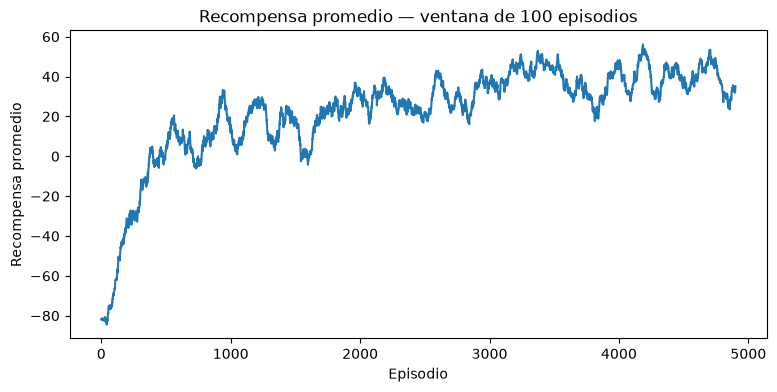

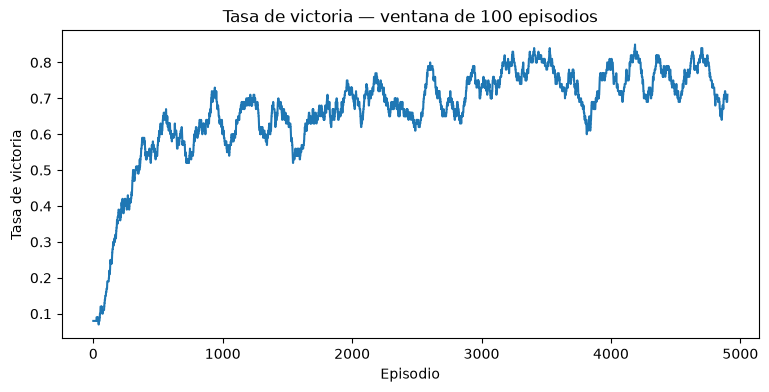

In [13]:
window = 100

moving_reward = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid",
)

moving_win_rate = np.convolve(
    wins,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(9, 4))
plt.plot(moving_reward)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Recompensa promedio — ventana de {window} episodios")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(moving_win_rate)
plt.xlabel("Episodio")
plt.ylabel("Tasa de victoria")
plt.title(f"Tasa de victoria — ventana de {window} episodios")
plt.show()


### Pregunta 5

A partir de las curvas:

1. ¿hay evidencia de aprendizaje?
2. ¿qué ocurre con la recompensa promedio?
3. ¿qué ocurre con la tasa de victoria?

**Respuesta.**

1. **¿Hay evidencia de aprendizaje? Sí, y muy clara.** Ambas curvas suben de
   forma sostenida desde el inicio. En números (medias móviles de 100
   episodios):

   | | Primeros 100 episodios | Últimos 100 episodios |
   |---|---:|---:|
   | Recompensa promedio | $-81.89$ | $+35.16$ |
   | Tasa de victoria | $0.08$ | $0.71$ |

2. **La recompensa promedio** arranca cerca de $-82$: el agente muere casi
   siempre y se lleva el $-100$ del fantasma. La subida más violenta ocurre en
   los primeros ~600 episodios (pasa de $-82$ a valores positivos), que es
   cuando aprende lo más rentable: **no morir**. Después mejora más despacio
   —refinando el orden en que recoge la comida— y se estabiliza oscilando
   entre $+35$ y $+50$ a partir del episodio ~3000.

3. **La tasa de victoria** sigue la misma forma: $0.08 \rightarrow 0.58$ hacia
   el episodio 600, y luego se asienta entre $0.70$ y $0.80$.

**La curva no es una recta suave, y eso es esperable**, por dos razones que no
son defectos de la implementación:

- el fantasma se mueve **al azar**, así que dos episodios con la misma
  política dan recompensas distintas;
- durante el entrenamiento $\epsilon$ nunca llega a 0 (se detiene en
  `epsilon_min = 0.02`), de modo que el agente sigue tomando acciones
  exploratorias que a veces le cuestan el episodio.

Por eso la curva de entrenamiento ($0.71$ de victorias) queda *por debajo* de
la evaluación greedy sin exploración ($0.835$): son dos cosas distintas.


## 11. Política aprendida


In [14]:
state = env.reset(seed=7)
decoded = env.decode_state(state)

print("Estado:", decoded)
print()

legal_actions = env.get_legal_actions()

for action in legal_actions:
    print(
        f"{ACTIONS[action]:>8} : "
        f"Q = {Q[state, action]:.3f}"
    )

best_value = max(Q[state, a] for a in legal_actions)

best_actions = [
    a for a in legal_actions
    if Q[state, a] == best_value
]

print()
print("Mejor(es) acción(es):", [ACTIONS[a] for a in best_actions])


Estado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)

   right : Q = 23.630
    down : Q = 10.857

Mejor(es) acción(es): ['right']


### Pregunta 6

Interprete los Q-values del estado inicial.

¿Qué acción prefiere el agente y qué significa que una acción tenga un Q-value mayor que otra?

**Respuesta.** El estado inicial es
`PacmanState(pacman=(1,1), ghost=(2,5), food_remaining=5)`. Solo hay dos
acciones legales (arriba e izquierda son pared) y el agente aprendió:

| Acción | Q-value |
|---|---:|
| `right` | **23.630** |
| `down` | 10.857 |

**El agente prefiere `right`.**

**Qué significa un Q-value mayor.** $Q(s,a)$ estima el **retorno total
descontado** que se obtiene al ejecutar $a$ en $s$ y después seguir la
política aprendida:

$$Q(s,a)=\mathbb{E}\Big[\textstyle\sum_{k\ge 0}\gamma^{k}R_{t+k+1}\Big]$$

No es la recompensa inmediata. De hecho **las dos acciones dan exactamente la
misma recompensa inmediata**, $-1$: ni $(1,2)$ ni $(2,1)$ tienen comida. Toda
la diferencia de $\approx 12.8$ puntos viene del **futuro**: empezando por la
derecha, Pac-Man recorre la fila 1 y recoge las comidas $(1,3)$ y $(1,5)$
pronto, y el orden que se abre después le permite limpiar el tablero sin
volver sobre sus pasos. Como $\gamma=0.95$, cobrar antes vale más que cobrar
después, así que la ruta más corta se traduce en un Q-value más alto.

Esto se confirma en el episodio reproducido más abajo: partiendo con `right`,
el agente termina el tablero en **20 pasos** con recompensa **+80**.


## 12. Reproducir un episodio


In [15]:
def greedy_action(Q, state, env):
    legal_actions = env.get_legal_actions()

    values = np.array([
        Q[state, action]
        for action in legal_actions
    ])

    best_value = np.max(values)

    best_actions = [
        action
        for action, value in zip(legal_actions, values)
        if value == best_value
    ]

    return random.choice(best_actions)


def play_episode(
    env,
    Q=None,
    random_policy=False,
    seed=20,
    max_steps=100,
):
    state = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for step in range(max_steps):

        if random_policy:
            action = random.choice(env.get_legal_actions())
        else:
            action = greedy_action(Q, state, env)

        next_state, reward, done, info = env.step(action)

        total_reward += reward
        state = next_state
        frames.append(env.render())

        if done:
            break

    return frames, total_reward, step + 1, info


def frames_to_video(frames, interval=300):
    fig = plt.figure(figsize=(7, 5))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True,
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


### Política aleatoria


In [16]:
frames_random, reward_random, steps_random, info_random = play_episode(
    env,
    random_policy=True,
    seed=20,
)

print("Reward:", reward_random)
print("Pasos :", steps_random)
print("Comió :", info_random["food_eaten"], "de", env.max_food)
print("Ganó  :", info_random["won"])

frames_to_video(frames_random)


Reward: -94
Pasos : 14
Comió : 2 de 5
Ganó  : False


### Política aprendida


In [17]:
frames_trained, reward_trained, steps_trained, info_trained = play_episode(
    env,
    Q=Q,
    random_policy=False,
    seed=20,
)

print("Reward:", reward_trained)
print("Pasos :", steps_trained)
print("Comió :", info_trained["food_eaten"], "de", env.max_food)
print("Ganó  :", info_trained["won"])

frames_to_video(frames_trained)


Reward: 80
Pasos : 20
Comió : 5 de 5
Ganó  : True


### Pregunta 7

Compare el episodio aleatorio con el episodio del agente entrenado.

Discuta:

- cantidad de movimientos;
- recompensa total;
- cantidad de comidas recolectadas;
- comportamiento frente al fantasma.

Explique por qué la recompensa acumulada favorece simultáneamente **comer**, **usar menos pasos** y **evitar morir**.

**Respuesta.** Comparación del mismo episodio (`seed=20`):

| | Política aleatoria | Política aprendida |
|---|---:|---:|
| Recompensa total | $-94$ | $\mathbf{+80}$ |
| Movimientos | 14 | 20 |
| Comidas recolectadas | 2 de 5 | **5 de 5** |
| ¿Ganó? | No | **Sí** |
| Final del episodio | atrapado por el fantasma | tablero limpio |

- **Movimientos.** El agente aleatorio "dura" menos pasos, pero no porque sea
  eficiente: el episodio se corta porque muere. Deshace constantemente su
  propio camino (avanza y retrocede sobre la misma celda). El agente entrenado
  usa 20 pasos y con ellos **termina la tarea**; el mínimo teórico rondaría
  los 14–15 pasos, así que está cerca del óptimo.
- **Recompensa total.** 174 puntos de diferencia. El grueso no viene de comer,
  sino de **no recibir el $-100$**.
- **Comidas.** 2/5 contra 5/5. El agente aleatorio tropieza con comida por
  casualidad; el entrenado la encadena en una ruta.
- **Comportamiento frente al fantasma.** Es la diferencia más visible en la
  animación. El agente entrenado **esquiva activamente**: en la mitad del
  episodio llega a $(4,5)$ con el fantasma a distancia 1 en $(3,5)$, retrocede
  hacia la izquierda y hacia arriba en lugar de seguir, y solo vuelve a por la
  comida de $(3,5)$ un par de pasos después, cuando el fantasma se ha alejado.
  El agente aleatorio, en cambio, camina directo hacia él. En la evaluación
  sobre 200 episodios esto es sistemático: **0 muertes**.

**Por qué una sola recompensa acumulada optimiza las tres cosas a la vez.**

Porque las tres se suman dentro del mismo retorno, con magnitudes deliberadamente
distintas:

$$G_t=\sum_{k\ge0}\gamma^{k}R_{t+k+1},\qquad
R\in\{\underbrace{-1}_{\text{paso}},\ \underbrace{+10}_{\text{comida}},\
\underbrace{-100}_{\text{fantasma}},\ \underbrace{+50}_{\text{tablero limpio}}\}$$

- **Evitar morir** domina la jerarquía: $-100$ equivale a 10 comidas o a 100
  pasos perdidos, y además **termina el episodio**, cancelando todo el $+50$ y
  las comidas que faltaban. Por eso es lo primero que el agente aprende.
- **Comer** es la única fuente de recompensa positiva por el camino, y el
  $+50$ final solo se cobra si se comen *todas*.
- **Usar menos pasos** sale gratis del $-1$ por paso: cualquier movimiento que
  no acerque a la meta resta. El descuento $\gamma=0.95$ refuerza lo mismo por
  otra vía —una comida dentro de 5 pasos vale $0.95^5\approx0.77$ de su
  valor—, así que dar rodeos también devalúa las recompensas futuras.

El agente nunca recibe la instrucción "come", "huye" ni "sé rápido": todas
esas conductas son consecuencia de maximizar un único escalar.


## 13. Evaluación final


In [18]:
def evaluate_policy(
    env,
    Q,
    episodes=200,
    max_steps=100,
):
    rewards = []
    lengths = []
    wins = []

    for episode in range(episodes):

        state = env.reset(seed=10000 + episode)
        total_reward = 0

        for step in range(max_steps):

            action = greedy_action(Q, state, env)

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)
        wins.append(int(info.get("won", False)))

    return {
        "reward_promedio": np.mean(rewards),
        "pasos_promedio": np.mean(lengths),
        "tasa_victoria": np.mean(wins),
    }


results = evaluate_policy(env, Q)
results


{'reward_promedio': np.float64(54.42),
 'pasos_promedio': np.float64(35.53),
 'tasa_victoria': np.float64(0.835)}

## Entrega

El notebook debe ejecutar completamente y contener:

1. Q-table correctamente inicializada;
2. política $\epsilon$-greedy;
3. actualización de Q-Learning;
4. ciclo de entrenamiento;
5. curva de aprendizaje;
6. interpretación de resultados;
7. comparación entre política aleatoria y política aprendida.

No se requiere modificar el código del ambiente.
